# DoubleML Tutorial 13: Sensitivity Analysis For Unobserved Confounding

This notebook is about a hard truth in causal inference: good machine learning does not remove the need for good identification assumptions. DoubleML can adjust flexibly for observed controls, but it still relies on a version of **unconfoundedness given the observed controls**. If an important common cause of treatment and outcome is missing, the estimate can be biased.

Sensitivity analysis asks a disciplined question:

> How strong would hidden confounding need to be to materially change the conclusion?

DoubleML's sensitivity tools do not discover the hidden variable. They do not prove that unobserved confounding is absent. Instead, they create a structured stress test. The stress test is controlled by three main ideas:

- `cf_y`: how much residual outcome variation a hidden confounder could explain;
- `cf_d`: how much the hidden confounder could change the treatment-side score representation;
- `rho`: how adversarially the outcome-side and treatment-side hidden components are aligned.

The most conservative setting is usually `rho = 1.0`, meaning the hidden confounding works in the direction that most weakens the reported conclusion.

This notebook uses a synthetic PLR design where we know the hidden confounder. We fit three models:

1. observed controls only,
2. observed controls plus imperfect proxy controls,
3. an oracle model that includes the hidden confounder.

Only the first two are realistic. The oracle model exists so students can see what hidden confounding is doing. After fitting the realistic proxy-adjusted model, we run DoubleML sensitivity analysis, calibrate the sensitivity parameters using observed proxy benchmarks, and build reporting language that does not overstate what sensitivity analysis can prove.

Expected runtime: usually under one minute. Most cells are fast; the benchmark cell refits a few DoubleML models to calibrate observed-variable benchmarks.

## Setup

This cell prepares output folders, imports DoubleML and plotting libraries, and suppresses only known notebook-environment noise. The rest of the notebook keeps code visible by default so the sensitivity workflow can be inspected line by line.

In [1]:
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR

from sklearn.base import clone
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

NOTEBOOK_PREFIX = "13"
RANDOM_SEED = 100
TRUE_THETA = 0.80
TREATMENT_COL = "treatment"
OUTCOME_COL = "outcome"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"DoubleML version: {dml.__version__}")
print(f"Output directory: {OUTPUT_DIR}")

DoubleML version: 0.11.2
Output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs


The setup confirms that the notebook is using the local DoubleML installation and the shared tutorial output folder. All saved artifacts in this notebook use prefix `13`.

## Helper Functions

These helpers keep the notebook focused on sensitivity logic. The most important helper is `extract_sensitivity_row()`, which turns DoubleML's nested `sensitivity_params` dictionary into a tidy row.

DoubleML stores robustness values as fractions. The helper records both the fraction and percentage form because the text summary prints percentages.

In [2]:
def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_dataset(df, filename):
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path


def model_x_cols(df, include_proxies=True, include_hidden=False):
    cols = [f"x{i:02d}" for i in range(8)]
    if include_proxies:
        cols += ["proxy_light", "proxy_strong"]
    if include_hidden:
        cols += ["hidden_intent"]
    return cols


def make_dml_data(df, include_proxies=True, include_hidden=False):
    return DoubleMLData(
        df,
        y_col=OUTCOME_COL,
        d_cols=TREATMENT_COL,
        x_cols=model_x_cols(df, include_proxies=include_proxies, include_hidden=include_hidden),
    )


def rmse_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_squared_error(y_true[mask], y_pred[mask]) ** 0.5


def mae_metric(y_true, y_pred):
    mask = ~np.isnan(y_true)
    return mean_absolute_error(y_true[mask], y_pred[mask])


def fit_plr(df, label, learner, include_proxies=True, include_hidden=False, n_folds=5, n_rep=2):
    model = DoubleMLPLR(
        make_dml_data(df, include_proxies=include_proxies, include_hidden=include_hidden),
        ml_l=clone(learner),
        ml_m=clone(learner),
        n_folds=n_folds,
        n_rep=n_rep,
    )
    model.fit()
    ci = model.confint(level=0.95).iloc[0]
    rmse = model.evaluate_learners(metric=rmse_metric)
    row = {
        "model": label,
        "uses_proxies": include_proxies,
        "uses_hidden_confounder": include_hidden,
        "theta_hat": float(model.coef[0]),
        "se": float(model.se[0]),
        "ci_95_lower": float(ci.iloc[0]),
        "ci_95_upper": float(ci.iloc[1]),
        "true_theta": TRUE_THETA,
        "bias_vs_true": float(model.coef[0] - TRUE_THETA),
        "rmse_ml_l": float(rmse["ml_l"][0, 0]),
        "rmse_ml_m": float(rmse["ml_m"][0, 0]),
    }
    return model, row


def extract_sensitivity_row(model, scenario, null_hypothesis):
    params = model.sensitivity_params
    return {
        "scenario": scenario,
        "cf_y": float(params["input"]["cf_y"]),
        "cf_d": float(params["input"]["cf_d"]),
        "rho": float(params["input"]["rho"]),
        "level": float(params["input"]["level"]),
        "null_hypothesis": float(np.asarray(params["input"]["null_hypothesis"]).ravel()[0]),
        "theta_hat": float(model.coef[0]),
        "theta_lower": float(params["theta"]["lower"][0]),
        "theta_upper": float(params["theta"]["upper"][0]),
        "ci_lower": float(params["ci"]["lower"][0]),
        "ci_upper": float(params["ci"]["upper"][0]),
        "rv": float(params["rv"][0]),
        "rva": float(params["rva"][0]),
        "rv_percent": float(100 * params["rv"][0]),
        "rva_percent": float(100 * params["rva"][0]),
        "true_theta": TRUE_THETA,
        "theta_lower_below_true": bool(float(params["theta"]["lower"][0]) <= TRUE_THETA),
        "ci_lower_below_true": bool(float(params["ci"]["lower"][0]) <= TRUE_THETA),
    }

The helper functions make three choices explicit: which controls are observed, whether proxy variables are included, and whether the hidden confounder is used in an oracle-only model.

## Sensitivity Vocabulary

This table defines the main quantities used in DoubleML sensitivity analysis. The names are compact in the API, so it helps to write their meaning before using them.

In [3]:
sensitivity_vocabulary = pd.DataFrame(
    [
        {
            "term": "cf_y",
            "meaning": "Share of residual outcome variation that a hidden confounder could explain.",
            "practical reading": "Larger values mean a hidden variable predicts the outcome residual more strongly.",
        },
        {
            "term": "cf_d",
            "meaning": "Share-like strength for how much hidden confounding can affect the treatment-side score representation.",
            "practical reading": "Larger values mean a hidden variable is more connected to treatment assignment after observed controls.",
        },
        {
            "term": "rho",
            "meaning": "Alignment between hidden outcome-side and treatment-side components.",
            "practical reading": "rho = 1 is adversarial for a positive effect; lower absolute values are less extreme.",
        },
        {
            "term": "theta bounds",
            "meaning": "Bounds on the point estimate under a sensitivity scenario.",
            "practical reading": "How far the effect estimate could move under the specified hidden confounding strength.",
        },
        {
            "term": "CI bounds",
            "meaning": "Sensitivity bounds that also include statistical uncertainty.",
            "practical reading": "The conservative uncertainty range under the specified hidden confounding scenario.",
        },
        {
            "term": "RV",
            "meaning": "Robustness value for moving the estimate to the null hypothesis.",
            "practical reading": "How strong confounding needs to be to move the point estimate to the target null.",
        },
        {
            "term": "RVa",
            "meaning": "Robustness value adjusted for statistical uncertainty.",
            "practical reading": "How strong confounding needs to be to make the uncertainty-adjusted conclusion touch the target null.",
        },
    ]
)

save_table(sensitivity_vocabulary, f"{NOTEBOOK_PREFIX}_sensitivity_vocabulary.csv")
display(sensitivity_vocabulary)

,term,meaning,practical reading
0,cf_y,Share of residual outcome variation that a hid...,Larger values mean a hidden variable predicts ...
1,cf_d,Share-like strength for how much hidden confou...,Larger values mean a hidden variable is more c...
2,rho,Alignment between hidden outcome-side and trea...,rho = 1 is adversarial for a positive effect; ...
3,theta bounds,Bounds on the point estimate under a sensitivi...,How far the effect estimate could move under t...
4,CI bounds,Sensitivity bounds that also include statistic...,The conservative uncertainty range under the s...
5,RV,Robustness value for moving the estimate to th...,How strong confounding needs to be to move the...
6,RVa,Robustness value adjusted for statistical unce...,How strong confounding needs to be to make the...


The main habit is to treat these values as stress-test parameters. They help structure a discussion about hidden confounding; they do not reveal whether the hidden confounder actually exists.

## Synthetic Hidden-Confounding Design

The synthetic data contains a hidden variable called `hidden_intent`. It affects both the treatment and outcome. In a real dataset this variable would not be observed. Here it is kept in the dataframe so we can compare realistic models against an oracle model.

We also create two observed proxy controls:

- `proxy_light`: weakly related to the hidden confounder,
- `proxy_strong`: more strongly related to the hidden confounder.

These proxies are useful for benchmark calibration. If omitting an observed proxy creates a certain amount of confounding, we can ask whether an unobserved factor of comparable strength would change the conclusion.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_800
n_controls = 8

x_array = rng.normal(size=(n_obs, n_controls))
sensitivity_df = pd.DataFrame(x_array, columns=[f"x{i:02d}" for i in range(n_controls)])
sensitivity_df.insert(0, "unit_id", np.arange(n_obs))

hidden_intent = rng.normal(size=n_obs)
sensitivity_df["hidden_intent"] = hidden_intent
sensitivity_df["proxy_light"] = 0.35 * hidden_intent + np.sqrt(1 - 0.35**2) * rng.normal(size=n_obs)
sensitivity_df["proxy_strong"] = 0.65 * hidden_intent + np.sqrt(1 - 0.65**2) * rng.normal(size=n_obs)

sensitivity_df["true_m"] = (
    0.55 * sensitivity_df["x00"]
    - 0.45 * sensitivity_df["x01"]
    + 0.25 * sensitivity_df["x02"]
    + 0.20 * sensitivity_df["x03"]
    + 0.45 * sensitivity_df["hidden_intent"]
)
sensitivity_df["true_g"] = (
    0.60 * sensitivity_df["x00"]
    + 0.35 * sensitivity_df["x04"]
    - 0.30 * sensitivity_df["x05"]
    + 0.25 * sensitivity_df["x06"]
    + 0.45 * sensitivity_df["hidden_intent"]
)

sensitivity_df[TREATMENT_COL] = sensitivity_df["true_m"] + rng.normal(scale=1.00, size=n_obs)
sensitivity_df[OUTCOME_COL] = TRUE_THETA * sensitivity_df[TREATMENT_COL] + sensitivity_df["true_g"] + rng.normal(scale=1.00, size=n_obs)

save_dataset(sensitivity_df, f"{NOTEBOOK_PREFIX}_synthetic_hidden_confounding_data.csv")
sensitivity_df.head()

,unit_id,x00,x01,x02,x03,x04,x05,x06,x07,hidden_intent,proxy_light,proxy_strong,true_m,true_g,treatment,outcome
0,0,-1.157550,0.289756,0.780854,0.543974,-0.961383,1.071009,0.701456,0.704973,0.682330,2.080038,0.127715,-0.155986,-0.869904,1.078075,0.667120
1,1,0.745063,1.104347,2.242972,-0.611493,0.047211,1.754235,-1.337980,0.325574,-0.175431,1.503571,0.354432,0.272329,-0.476148,0.424389,1.636021
2,2,-0.689118,-0.019822,0.474753,-1.931101,-0.992478,-1.405471,-0.231096,-0.688847,-0.216358,0.110206,0.196659,-0.734988,-0.494332,0.970589,-1.098867
3,3,1.515106,-0.603172,1.713684,-0.406249,0.271410,0.039840,0.011518,-1.127178,1.137582,0.586389,-0.308401,1.963818,1.506896,1.521296,1.159019
4,4,0.334713,0.383892,0.237836,0.621412,-0.819246,-0.297579,-0.661563,-1.704170,0.453553,0.146421,-0.363620,0.399181,0.042074,0.896702,1.039117


The first rows include the hidden confounder because this is a controlled teaching example. In applied work, the hidden variable is exactly what we do not have.

## Data Dictionary And Audit

The audit records what each field means and shows that `hidden_intent` is related to treatment, outcome, and both proxy variables. This creates the conditions for hidden-confounding bias.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {"column": "unit_id", "role": "identifier", "description": "Synthetic row identifier; excluded from modeling."},
        {"column": "x00-x07", "role": "observed controls", "description": "Observed pre-treatment controls."},
        {"column": "proxy_light", "role": "observed proxy control", "description": "Weak observed proxy for hidden_intent."},
        {"column": "proxy_strong", "role": "observed proxy control", "description": "Stronger observed proxy for hidden_intent."},
        {"column": "hidden_intent", "role": "oracle only", "description": "Unobserved confounder in realistic analyses; included here only for simulation checks."},
        {"column": "true_m", "role": "oracle only", "description": "True treatment nuisance function."},
        {"column": "true_g", "role": "oracle only", "description": "True outcome nuisance component."},
        {"column": "treatment", "role": "treatment", "description": "Continuous treatment affected by observed controls and hidden_intent."},
        {"column": "outcome", "role": "outcome", "description": "Continuous outcome affected by treatment, observed controls, and hidden_intent."},
    ]
)

correlation_audit = pd.DataFrame(
    [
        {"variable": col, "corr_with_hidden_intent": sensitivity_df[col].corr(sensitivity_df["hidden_intent"])}
        for col in ["treatment", "outcome", "proxy_light", "proxy_strong", "true_m", "true_g"]
    ]
)

overall_audit = pd.DataFrame(
    {
        "n_rows": [len(sensitivity_df)],
        "n_observed_base_controls": [8],
        "n_proxy_controls": [2],
        "true_theta": [TRUE_THETA],
        "missing_cells": [int(sensitivity_df.isna().sum().sum())],
    }
)

save_table(field_dictionary, f"{NOTEBOOK_PREFIX}_field_dictionary.csv")
save_table(correlation_audit, f"{NOTEBOOK_PREFIX}_hidden_confounding_correlation_audit.csv")
save_table(overall_audit, f"{NOTEBOOK_PREFIX}_overall_data_audit.csv")

display(field_dictionary)
display(overall_audit)
display(correlation_audit)

,column,role,description
0,unit_id,identifier,Synthetic row identifier; excluded from modeling.
1,x00-x07,observed controls,Observed pre-treatment controls.
2,proxy_light,observed proxy control,Weak observed proxy for hidden_intent.
3,proxy_strong,observed proxy control,Stronger observed proxy for hidden_intent.
4,hidden_intent,oracle only,Unobserved confounder in realistic analyses; i...
5,true_m,oracle only,True treatment nuisance function.
6,true_g,oracle only,True outcome nuisance component.
7,treatment,treatment,Continuous treatment affected by observed cont...
8,outcome,outcome,"Continuous outcome affected by treatment, obse..."


,n_rows,n_observed_base_controls,n_proxy_controls,true_theta,missing_cells
0,1800,8,2,0.8,0


,variable,corr_with_hidden_intent
0,treatment,0.316607
1,outcome,0.384895
2,proxy_light,0.360556
3,proxy_strong,0.646839
4,true_m,0.483226
5,true_g,0.453015


The proxies are correlated with the hidden confounder but do not perfectly reveal it. This is the useful middle ground for sensitivity teaching: adjustment helps, but hidden confounding can still remain.

## Hidden Confounding Design Diagram

The diagram shows the logic of the synthetic design. Solid arrows are observed parts of the analysis. Dashed arrows mark the hidden path that sensitivity analysis is stress-testing.

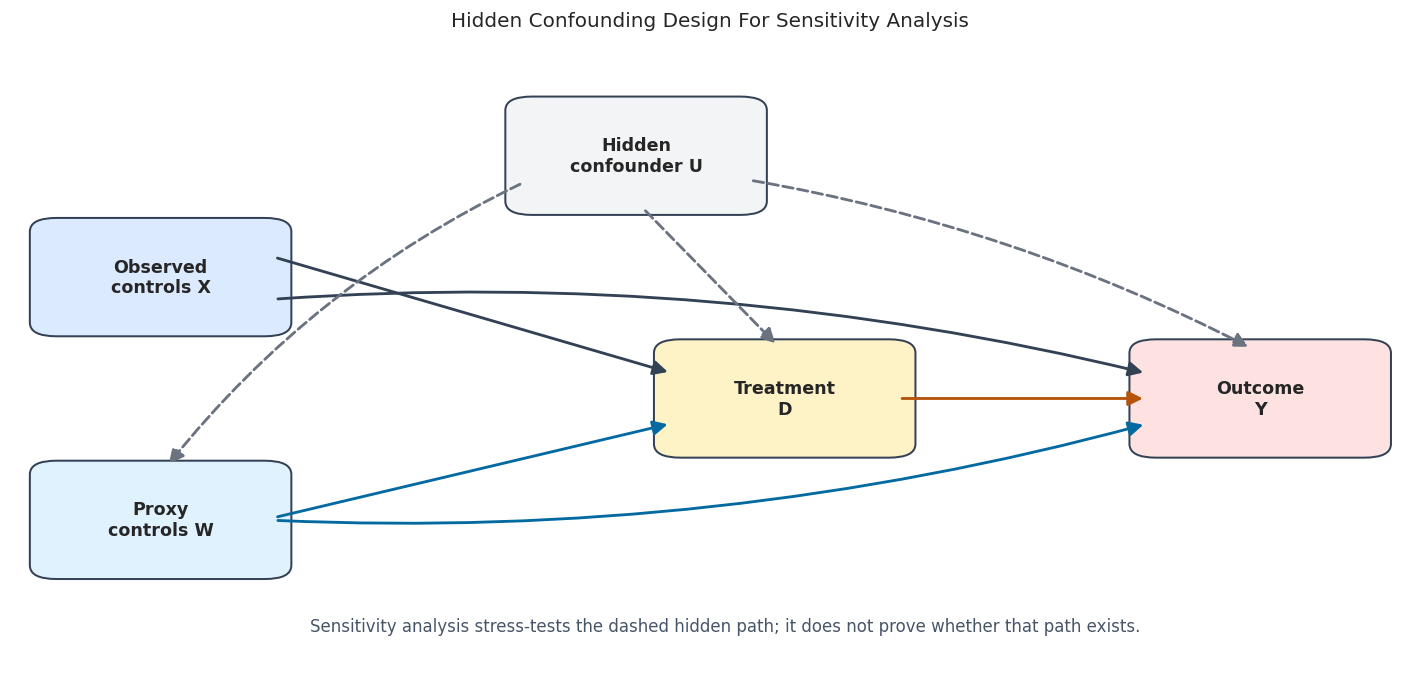

In [6]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

nodes = {
    "X": {"xy": (0.10, 0.66), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "W": {"xy": (0.10, 0.34), "label": "Proxy\ncontrols W", "color": "#e0f2fe"},
    "U": {"xy": (0.42, 0.82), "label": "Hidden\nconfounder U", "color": "#f3f4f6"},
    "D": {"xy": (0.52, 0.50), "label": "Treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.84, 0.50), "label": "Outcome\nY", "color": "#fee2e2"},
}

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.set_axis_off()
ax.set_xlim(0.0, 0.94)
ax.set_ylim(0.15, 0.96)
box_w, box_h = 0.14, 0.12


def anchor(name, side):
    x, y = nodes[name]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return (x + dx, y + dy)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=8,
        shrinkB=8,
        zorder=5,
    )
    ax.add_patch(arrow)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=4)

draw_arrow(anchor("X", "upper_right"), anchor("D", "upper_left"))
draw_arrow(anchor("X", "lower_right"), anchor("Y", "upper_left"), rad=-0.08)
draw_arrow(anchor("W", "right"), anchor("D", "lower_left"), color="#0369a1")
draw_arrow(anchor("W", "right"), anchor("Y", "lower_left"), color="#0369a1", rad=0.08)
draw_arrow(anchor("D", "right"), anchor("Y", "left"), color="#b45309")
draw_arrow(anchor("U", "bottom"), anchor("D", "top"), color="#6b7280", style="dashed")
draw_arrow(anchor("U", "lower_right"), anchor("Y", "top"), color="#6b7280", style="dashed", rad=-0.08)
draw_arrow(anchor("U", "lower_left"), anchor("W", "top"), color="#6b7280", style="dashed", rad=0.12)

ax.text(
    0.48,
    0.20,
    "Sensitivity analysis stress-tests the dashed hidden path; it does not prove whether that path exists.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Hidden Confounding Design For Sensitivity Analysis", pad=14)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_design.png", bbox_inches="tight")
plt.show()

The proxy controls block part of the hidden path because they carry information about `hidden_intent`. The remaining dashed path is the reason we still need a sensitivity stress test.

## Fit Realistic And Oracle Models

We fit three PLR models:

- observed base controls only,
- observed base controls plus proxies,
- oracle model with the hidden confounder.

The oracle model is not a realistic analysis. It is a teaching reference that shows what would happen if the missing confounder were actually observed.

In [7]:
base_learner = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 15))),
    ]
)

model_specs = [
    {"label": "Observed X only", "include_proxies": False, "include_hidden": False},
    {"label": "Observed X + proxies", "include_proxies": True, "include_hidden": False},
    {"label": "Oracle with hidden confounder", "include_proxies": True, "include_hidden": True},
]

fitted_models = {}
model_rows = []
for spec in model_specs:
    model, row = fit_plr(
        sensitivity_df,
        label=spec["label"],
        learner=base_learner,
        include_proxies=spec["include_proxies"],
        include_hidden=spec["include_hidden"],
    )
    fitted_models[spec["label"]] = model
    model_rows.append(row)

model_comparison = pd.DataFrame(model_rows)
save_table(model_comparison, f"{NOTEBOOK_PREFIX}_model_comparison.csv")
display(model_comparison)

,model,uses_proxies,uses_hidden_confounder,theta_hat,se,ci_95_lower,ci_95_upper,true_theta,bias_vs_true,rmse_ml_l,rmse_ml_m
0,Observed X only,False,False,0.981799,0.024192,0.934383,1.029215,0.8,0.181799,1.504721,1.073815
1,Observed X + proxies,True,False,0.892058,0.023905,0.845206,0.938911,0.8,0.092058,1.380630,1.030034
2,Oracle with hidden confounder,True,True,0.805303,0.024007,0.758250,0.852355,0.8,0.005303,1.268940,0.984933


The proxy-adjusted model moves toward the oracle estimate, but it does not fully remove hidden-confounding bias. This is exactly the setting where sensitivity analysis is useful: the main estimate is credible only if remaining hidden confounding is not too strong.

## Model Comparison Plot

The plot below shows how estimates move as more information about the hidden confounder becomes available. The red dashed line is the true simulated treatment effect.

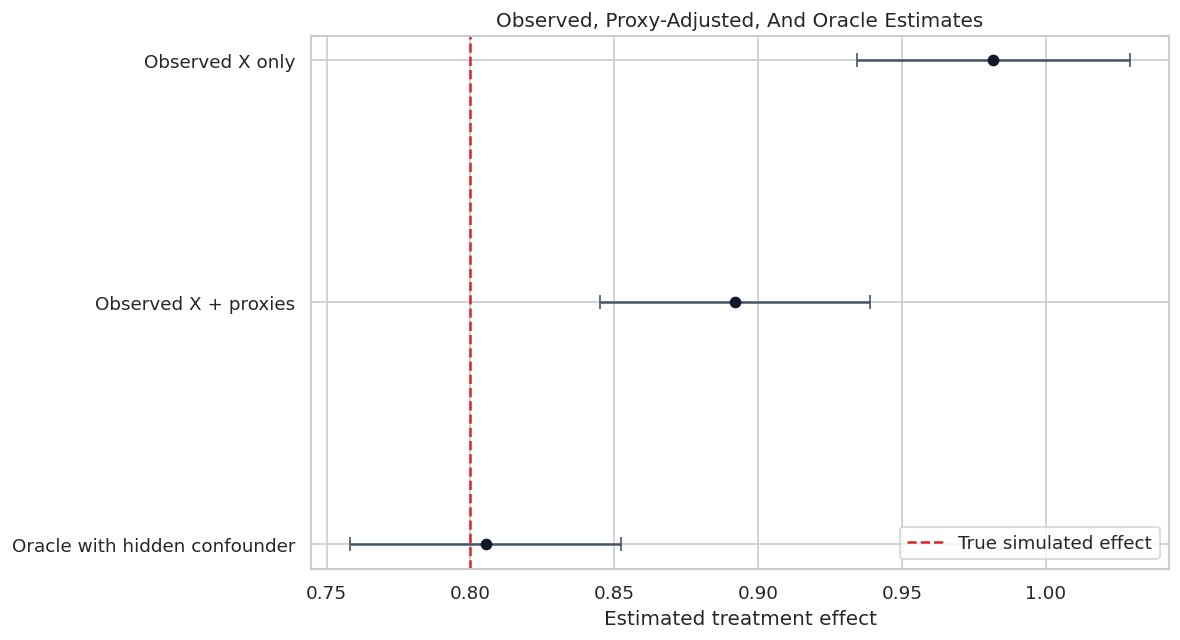

In [8]:
plot_model_comparison = model_comparison.sort_values("theta_hat")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=plot_model_comparison["theta_hat"],
    y=plot_model_comparison["model"],
    xerr=1.96 * plot_model_comparison["se"],
    fmt="o",
    color="#111827",
    ecolor="#475569",
    capsize=4,
)
ax.axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True simulated effect")
ax.set_title("Observed, Proxy-Adjusted, And Oracle Estimates")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_model_comparison.png", bbox_inches="tight")
plt.show()

The realistic proxy-adjusted model is still above the true effect. Sensitivity analysis will ask how strong the remaining hidden confounding would need to be to move the estimate meaningfully.

## Run A Primary Sensitivity Scenario

We use the proxy-adjusted model as the main realistic specification. The first sensitivity scenario uses `cf_y = 0.04`, `cf_d = 0.04`, and `rho = 1.0`. This is a modest but adversarial hidden-confounding scenario.

The null hypothesis is set to zero because a common reporting question is whether the result could be moved to no effect.

In [9]:
main_model = fitted_models["Observed X + proxies"]
main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=0.0)

primary_sensitivity = pd.DataFrame(
    [extract_sensitivity_row(main_model, scenario="Modest adversarial hidden confounding", null_hypothesis=0.0)]
)

summary_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_primary_sensitivity_summary.txt"
summary_path.write_text(main_model.sensitivity_summary)

save_table(primary_sensitivity, f"{NOTEBOOK_PREFIX}_primary_sensitivity.csv")
print(main_model.sensitivity_summary)
display(primary_sensitivity)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.04; cf_d=0.04, rho=1.0

------------------ Bounds with CI    ------------------
           CI lower  theta lower     theta  theta upper  CI upper
treatment  0.811904     0.851186  0.892058     0.932931  0.972348

------------------ Robustness Values ------------------
           H_0     RV (%)    RVa (%)
treatment  0.0  57.848598  55.900165


,scenario,cf_y,cf_d,rho,level,null_hypothesis,theta_hat,theta_lower,theta_upper,ci_lower,ci_upper,rv,rva,rv_percent,rva_percent,true_theta,theta_lower_below_true,ci_lower_below_true
0,Modest adversarial hidden confounding,0.04,0.04,1.0,0.95,0.0,0.892058,0.851186,0.932931,0.811904,0.972348,0.578486,0.559002,57.848598,55.900165,0.8,False,False


The bounds show how far the estimate and confidence interval could move under the chosen scenario. The robustness values are large for the zero null, meaning a fairly strong hidden confounder would be needed to move this positive estimate all the way to zero.

## Sensitivity Bounds Plot

This plot separates three quantities that are easy to mix up: the original estimate, the sensitivity-adjusted point-estimate bounds, and the sensitivity-adjusted confidence bounds.

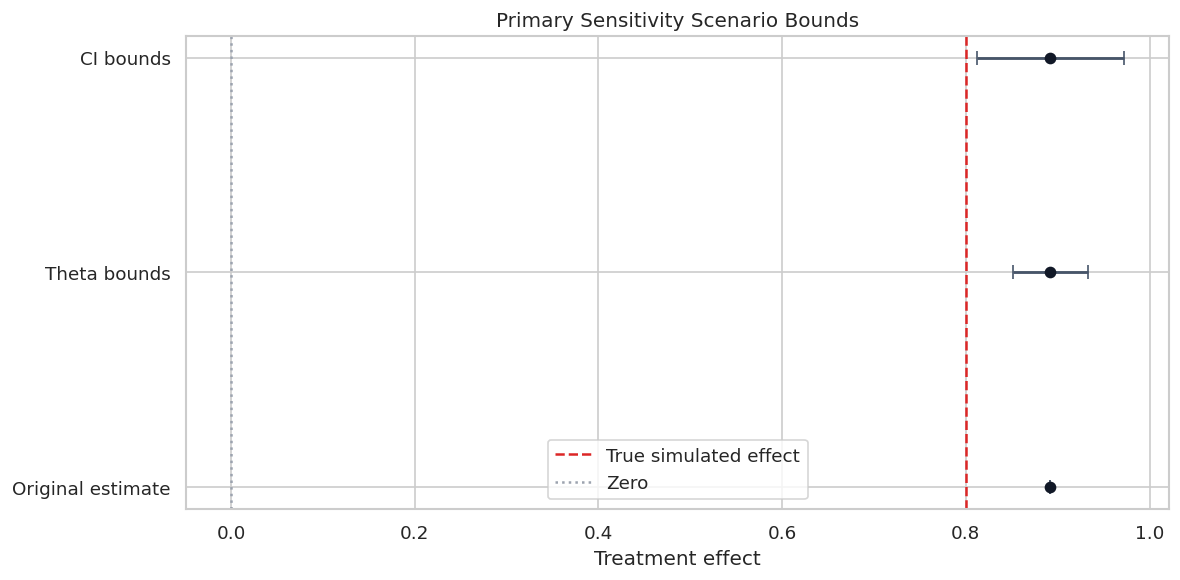

In [10]:
primary = primary_sensitivity.iloc[0]
bounds_plot = pd.DataFrame(
    [
        {"quantity": "Original estimate", "lower": main_model.coef[0], "center": main_model.coef[0], "upper": main_model.coef[0]},
        {"quantity": "Theta bounds", "lower": primary["theta_lower"], "center": main_model.coef[0], "upper": primary["theta_upper"]},
        {"quantity": "CI bounds", "lower": primary["ci_lower"], "center": main_model.coef[0], "upper": primary["ci_upper"]},
    ]
)

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in bounds_plot.iterrows():
    ax.errorbar(
        x=row["center"],
        y=row["quantity"],
        xerr=[[row["center"] - row["lower"]], [row["upper"] - row["center"]]],
        fmt="o",
        color="#111827",
        ecolor="#475569",
        capsize=4,
        linewidth=1.7,
    )
ax.axvline(TRUE_THETA, color="#dc2626", linestyle="--", linewidth=1.5, label="True simulated effect")
ax.axvline(0, color="#9ca3af", linestyle=":", linewidth=1.5, label="Zero")
ax.set_title("Primary Sensitivity Scenario Bounds")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_primary_sensitivity_bounds.png", bbox_inches="tight")
plt.show()

The sensitivity-adjusted confidence bound is wider than the point-estimate bound because it combines hidden-confounding stress with statistical uncertainty.

## Sensitivity Grid

A single scenario can hide how the conclusion changes across parameter choices. This grid evaluates many combinations of `cf_y` and `cf_d` at `rho = 1.0`.

The grid is not a new model fit. It reuses the fitted DoubleML score objects and evaluates sensitivity formulas across possible hidden-confounding strengths.

In [11]:
cf_values = np.linspace(0.0, 0.12, 25)
grid_rows = []
for cf_y in cf_values:
    for cf_d in cf_values:
        main_model.sensitivity_analysis(cf_y=float(cf_y), cf_d=float(cf_d), rho=1.0, level=0.95, null_hypothesis=0.0)
        grid_rows.append(extract_sensitivity_row(main_model, scenario="grid", null_hypothesis=0.0))

sensitivity_grid = pd.DataFrame(grid_rows)
save_table(sensitivity_grid, f"{NOTEBOOK_PREFIX}_sensitivity_grid.csv")

# Restore the primary scenario after grid evaluation.
main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=0.0)

display(sensitivity_grid.head())

,scenario,cf_y,cf_d,rho,level,null_hypothesis,theta_hat,theta_lower,theta_upper,ci_lower,ci_upper,rv,rva,rv_percent,rva_percent,true_theta,theta_lower_below_true,ci_lower_below_true
0,grid,0.0,0.000,1.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.578486,0.559002,57.848598,55.900165,0.8,False,False
1,grid,0.0,0.005,1.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.578486,0.559002,57.848598,55.900165,0.8,False,False
2,grid,0.0,0.010,1.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.578486,0.559002,57.848598,55.900165,0.8,False,False
3,grid,0.0,0.015,1.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.578486,0.559002,57.848598,55.900165,0.8,False,False
4,grid,0.0,0.020,1.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.578486,0.559002,57.848598,55.900165,0.8,False,False


The grid table records lower and upper bounds for every pair of sensitivity parameters. The next figure turns those rows into a contour-style stress map.

## Sensitivity Contour Plot

The contour plot shows the lower theta bound across the `cf_y` and `cf_d` grid. Benchmark points from observed proxy variables will be added in the next section; for now this plot shows the stress surface itself.

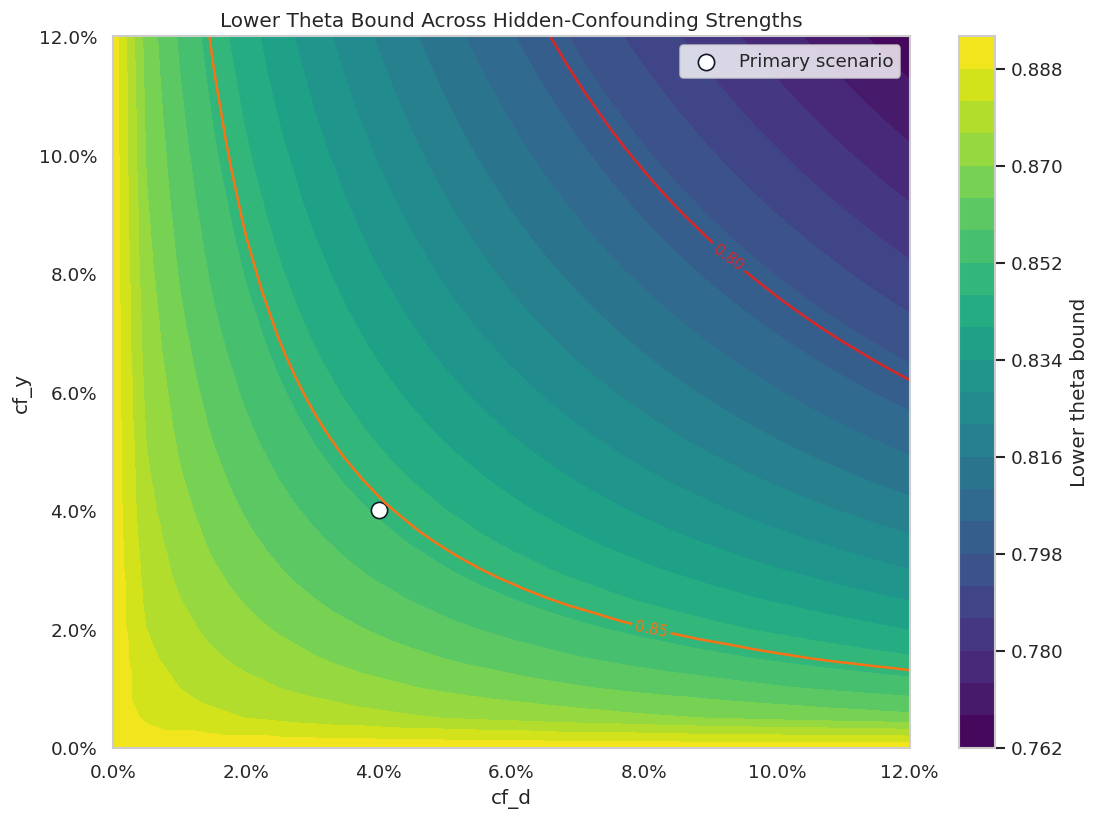

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 7))
contour = ax.tricontourf(
    sensitivity_grid["cf_d"],
    sensitivity_grid["cf_y"],
    sensitivity_grid["theta_lower"],
    levels=24,
    cmap="viridis",
)
level_lines = ax.tricontour(
    sensitivity_grid["cf_d"],
    sensitivity_grid["cf_y"],
    sensitivity_grid["theta_lower"],
    levels=[TRUE_THETA, 0.85],
    colors=["#dc2626", "#f97316"],
    linewidths=1.5,
)
ax.clabel(level_lines, inline=True, fontsize=9, fmt="%.2f")
ax.scatter([0.04], [0.04], color="#ffffff", edgecolor="#111827", s=95, label="Primary scenario")
ax.set_title("Lower Theta Bound Across Hidden-Confounding Strengths")
ax.set_xlabel("cf_d")
ax.set_ylabel("cf_y")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
fig.colorbar(contour, ax=ax, label="Lower theta bound")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_grid_lower_bound.png", bbox_inches="tight")
plt.show()

Moving up and right makes the hidden confounder stronger. The lower bound declines as the hidden confounder is allowed to explain more residual outcome and treatment-side variation.

## Benchmarking With Observed Proxy Variables

`DoubleML.sensitivity_benchmark()` calibrates sensitivity parameters using observed controls. The idea is to temporarily treat an observed variable as if it had been omitted, then measure how much that omission would matter.

This is useful because raw `cf_y` and `cf_d` values are hard to reason about. Benchmarks give them scale.

In [13]:
benchmark_specs = [
    ("proxy_light omitted", ["proxy_light"]),
    ("proxy_strong omitted", ["proxy_strong"]),
    ("both proxies omitted", ["proxy_light", "proxy_strong"]),
]

benchmark_rows = []
for benchmark_name, benchmark_cols in benchmark_specs:
    benchmark = main_model.sensitivity_benchmark(benchmark_cols).reset_index().rename(columns={"index": "treatment"})
    benchmark["benchmark"] = benchmark_name
    benchmark["benchmarking_set"] = ", ".join(benchmark_cols)
    benchmark_rows.append(benchmark)

benchmark_results = pd.concat(benchmark_rows, ignore_index=True)
save_table(benchmark_results, f"{NOTEBOOK_PREFIX}_sensitivity_benchmarks.csv")
display(benchmark_results)

,treatment,cf_y,cf_d,rho,delta_theta,benchmark,benchmarking_set
0,treatment,0.002367,0.011438,1.0,0.006019,proxy_light omitted,proxy_light
1,treatment,0.067721,0.060162,1.0,0.064486,proxy_strong omitted,proxy_strong
2,treatment,0.080617,0.090197,1.0,0.083554,both proxies omitted,"proxy_light, proxy_strong"


The stronger proxy creates larger benchmark values. The combined proxy benchmark gives a concrete reference for a hidden confounder with strength comparable to the observed proxy information.

## Benchmark-Calibrated Scenario

Now we turn the combined proxy benchmark into a sensitivity scenario. This asks: if the remaining hidden confounder were as strong as the observed proxy information, how far could the estimate move?

In [14]:
combined_benchmark = benchmark_results.query("benchmark == 'both proxies omitted'").iloc[0]
benchmark_cf_y = float(combined_benchmark["cf_y"])
benchmark_cf_d = float(combined_benchmark["cf_d"])
benchmark_rho = float(combined_benchmark["rho"])

main_model.sensitivity_analysis(
    cf_y=benchmark_cf_y,
    cf_d=benchmark_cf_d,
    rho=benchmark_rho,
    level=0.95,
    null_hypothesis=0.0,
)
benchmark_sensitivity = pd.DataFrame(
    [extract_sensitivity_row(main_model, scenario="Observed proxy benchmark scenario", null_hypothesis=0.0)]
)

scenario_comparison = pd.concat([primary_sensitivity, benchmark_sensitivity], ignore_index=True)
save_table(benchmark_sensitivity, f"{NOTEBOOK_PREFIX}_benchmark_sensitivity.csv")
save_table(scenario_comparison, f"{NOTEBOOK_PREFIX}_scenario_comparison.csv")

display(scenario_comparison)

# Restore primary scenario for later examples.
main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=0.0)

,scenario,cf_y,cf_d,rho,level,null_hypothesis,theta_hat,theta_lower,theta_upper,ci_lower,ci_upper,rv,rva,rv_percent,rva_percent,true_theta,theta_lower_below_true,ci_lower_below_true
0,Modest adversarial hidden confounding,0.040000,0.040000,1.0,0.95,0.0,0.892058,0.851186,0.932931,0.811904,0.972348,0.578486,0.559002,57.848598,55.900165,0.8,False,False
1,Observed proxy benchmark scenario,0.080617,0.090197,1.0,0.95,0.0,0.892058,0.802554,0.981563,0.763239,1.021172,0.578486,0.559002,57.848598,55.900165,0.8,False,True


The benchmark-calibrated scenario is stronger than the primary scenario. It moves the lower bound closer to the true simulated effect, showing how benchmark calibration can make sensitivity analysis more concrete.

## Sensitivity Grid With Benchmarks

The same contour plot becomes more useful after adding benchmark points. The benchmark points show where observed proxy omissions sit on the hidden-confounding grid.

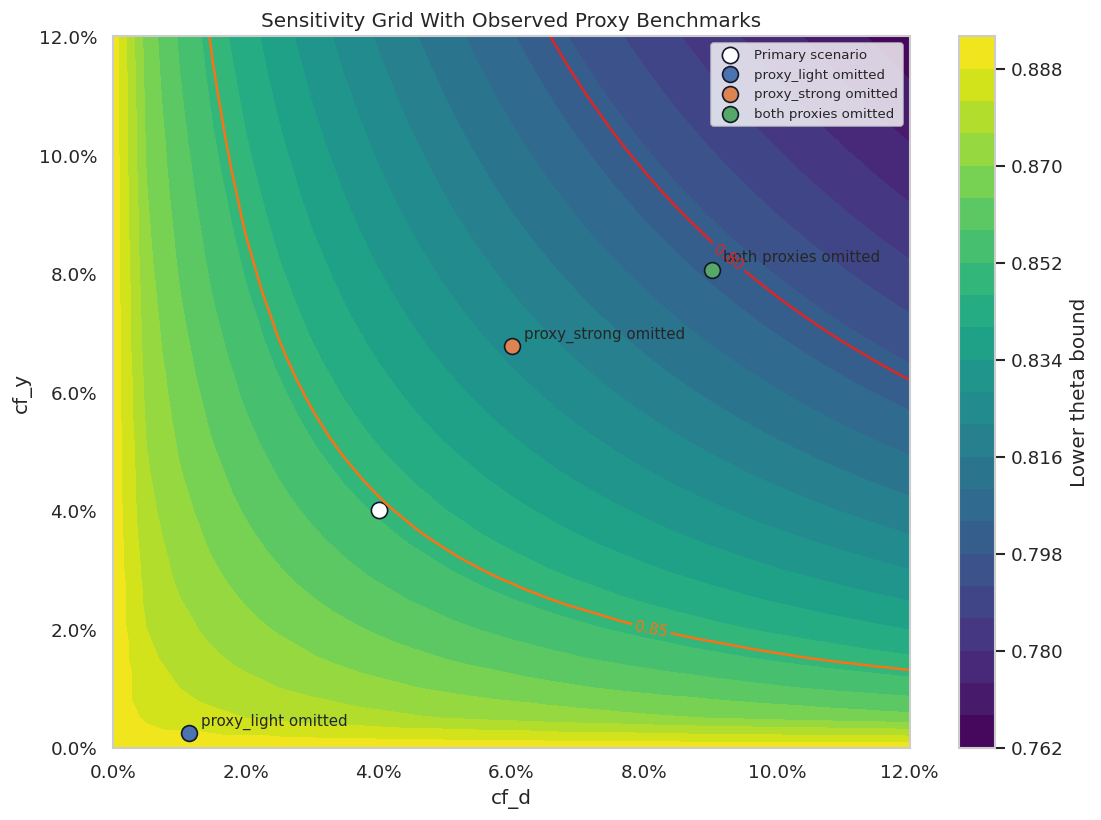

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 7))
contour = ax.tricontourf(
    sensitivity_grid["cf_d"],
    sensitivity_grid["cf_y"],
    sensitivity_grid["theta_lower"],
    levels=24,
    cmap="viridis",
)
level_lines = ax.tricontour(
    sensitivity_grid["cf_d"],
    sensitivity_grid["cf_y"],
    sensitivity_grid["theta_lower"],
    levels=[TRUE_THETA, 0.85],
    colors=["#dc2626", "#f97316"],
    linewidths=1.5,
)
ax.clabel(level_lines, inline=True, fontsize=9, fmt="%.2f")
ax.scatter([0.04], [0.04], color="#ffffff", edgecolor="#111827", s=95, label="Primary scenario")
for _, row in benchmark_results.iterrows():
    ax.scatter(row["cf_d"], row["cf_y"], s=90, edgecolor="#111827", label=row["benchmark"])
    ax.annotate(row["benchmark"], (row["cf_d"], row["cf_y"]), textcoords="offset points", xytext=(7, 5), fontsize=9)
ax.set_title("Sensitivity Grid With Observed Proxy Benchmarks")
ax.set_xlabel("cf_d")
ax.set_ylabel("cf_y")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
fig.colorbar(contour, ax=ax, label="Lower theta bound")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_grid_with_benchmarks.png", bbox_inches="tight")
plt.show()

The benchmark points make the grid less abstract. A reader can compare the assumed hidden-confounding scenario to the impact of omitting observed proxy variables.

## Native DoubleML Sensitivity Plot

DoubleML also provides an interactive Plotly sensitivity plot. We save it as HTML so it can be opened separately without requiring static image export support.

In [16]:
benchmark_plot_dict = {
    "cf_y": benchmark_results["cf_y"].to_numpy(),
    "cf_d": benchmark_results["cf_d"].to_numpy(),
    "name": benchmark_results["benchmark"].to_list(),
}

native_sensitivity_plot = main_model.sensitivity_plot(
    idx_treatment=0,
    value="theta",
    rho=1.0,
    level=0.95,
    null_hypothesis=0.0,
    include_scenario=True,
    benchmarks=benchmark_plot_dict,
    grid_bounds=(0.12, 0.12),
    grid_size=50,
)

native_plot_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_native_doubleml_sensitivity_plot.html"
native_sensitivity_plot.write_html(native_plot_path)

display(Markdown(f"Native DoubleML sensitivity plot written to `{native_plot_path}`"))

Native DoubleML sensitivity plot written to `/home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/13_native_doubleml_sensitivity_plot.html`

The native plot is useful for exploration, while the static Matplotlib figures above are easier to include in reports and version-controlled artifacts.

## Role Of Rho

The `rho` parameter controls the alignment between hidden outcome-side and treatment-side components. For a positive estimated effect, `rho = 1` is the adversarial direction that most weakens the effect. Smaller absolute values imply less aligned hidden confounding.

In [17]:
rho_rows = []
for rho in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=rho, level=0.95, null_hypothesis=0.0)
    rho_rows.append(extract_sensitivity_row(main_model, scenario=f"rho={rho}", null_hypothesis=0.0))

rho_sensitivity = pd.DataFrame(rho_rows)
save_table(rho_sensitivity, f"{NOTEBOOK_PREFIX}_rho_sensitivity.csv")
display(rho_sensitivity)

main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=0.0)

,scenario,cf_y,cf_d,rho,level,null_hypothesis,theta_hat,theta_lower,theta_upper,ci_lower,ci_upper,rv,rva,rv_percent,rva_percent,true_theta,theta_lower_below_true,ci_lower_below_true
0,rho=-1.0,0.04,0.04,-1.0,0.95,0.0,0.892058,0.851186,0.932931,0.811904,0.972348,0.578486,0.559002,57.848598,55.900165,0.8,False,False
1,rho=-0.5,0.04,0.04,-0.5,0.95,0.0,0.892058,0.871622,0.912495,0.832328,0.951856,0.798981,0.783445,79.898125,78.344524,0.8,False,False
2,rho=0.0,0.04,0.04,0.0,0.95,0.0,0.892058,0.892058,0.892058,0.852738,0.931378,0.999894,0.999894,99.989404,99.989404,0.8,False,False
3,rho=0.5,0.04,0.04,0.5,0.95,0.0,0.892058,0.871622,0.912495,0.832328,0.951856,0.798981,0.783445,79.898125,78.344524,0.8,False,False
4,rho=1.0,0.04,0.04,1.0,0.95,0.0,0.892058,0.851186,0.932931,0.811904,0.972348,0.578486,0.559002,57.848598,55.900165,0.8,False,False


The lower bound is most conservative when `rho` is positive and large. Reporting the `rho` choice helps readers understand whether the sensitivity scenario is adversarial or mild.

## Rho Sensitivity Plot

This plot shows how the lower and upper theta bounds change as `rho` varies while `cf_y` and `cf_d` stay fixed.

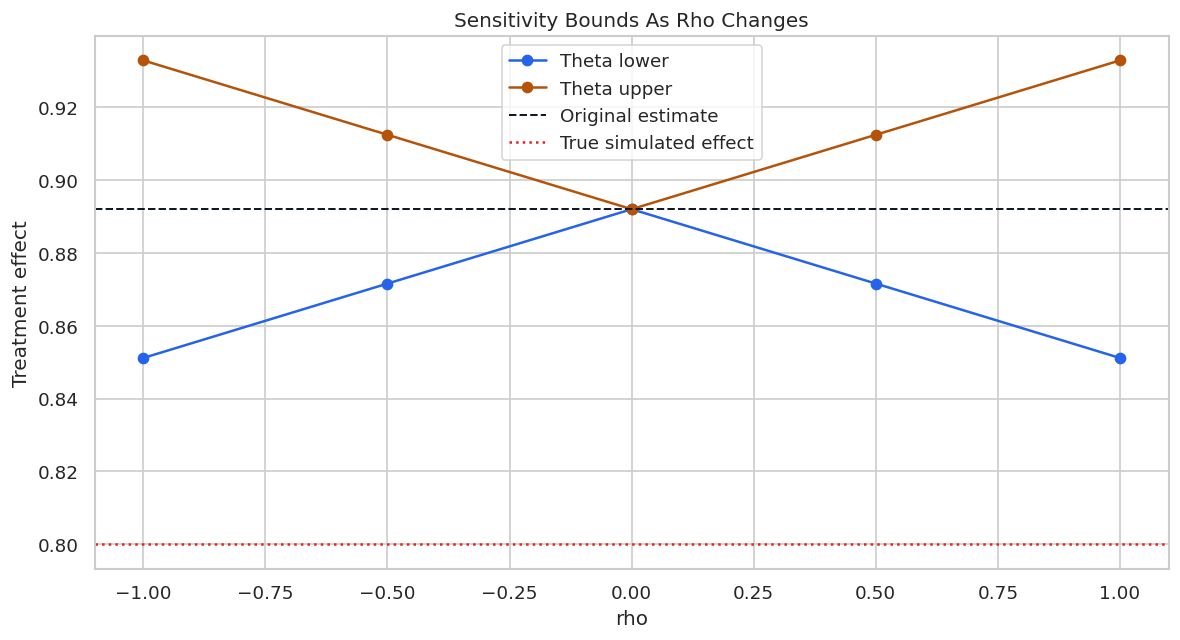

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(rho_sensitivity["rho"], rho_sensitivity["theta_lower"], marker="o", label="Theta lower", color="#2563eb")
ax.plot(rho_sensitivity["rho"], rho_sensitivity["theta_upper"], marker="o", label="Theta upper", color="#b45309")
ax.axhline(main_model.coef[0], color="#111827", linestyle="--", linewidth=1.2, label="Original estimate")
ax.axhline(TRUE_THETA, color="#dc2626", linestyle=":", linewidth=1.5, label="True simulated effect")
ax.set_title("Sensitivity Bounds As Rho Changes")
ax.set_xlabel("rho")
ax.set_ylabel("Treatment effect")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_rho_sensitivity.png", bbox_inches="tight")
plt.show()

The bounds widen in the adversarial direction as alignment increases. This is why `rho = 1` is a common conservative default for a positive effect.

## Robustness Values For Different Null Hypotheses

Robustness values depend on the null hypothesis. A null of zero asks how strong hidden confounding must be to erase the effect. In this simulation, we can also ask how strong hidden confounding must be to move the estimate to the known true effect. That second question is simulation-only, because real analyses do not know the true effect.

In [19]:
null_rows = []
for null_value in [0.0, TRUE_THETA, 0.85, 0.90]:
    main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=float(null_value))
    null_rows.append(extract_sensitivity_row(main_model, scenario=f"null={null_value:.2f}", null_hypothesis=float(null_value)))

null_sensitivity = pd.DataFrame(null_rows)
save_table(null_sensitivity, f"{NOTEBOOK_PREFIX}_robustness_by_null.csv")
display(null_sensitivity[["scenario", "null_hypothesis", "rv_percent", "rva_percent", "theta_lower", "theta_upper", "ci_lower", "ci_upper"]])

main_model.sensitivity_analysis(cf_y=0.04, cf_d=0.04, rho=1.0, level=0.95, null_hypothesis=0.0)

,scenario,null_hypothesis,rv_percent,rva_percent,theta_lower,theta_upper,ci_lower,ci_upper
0,null=0.00,0.00,57.848598,55.900165,0.851186,0.932931,0.811904,0.972348
1,null=0.80,0.80,8.782032,5.134359,0.851186,0.932931,0.811904,0.972348
2,null=0.85,0.85,4.113657,0.273482,0.851186,0.932931,0.811904,0.972348
3,null=0.90,0.90,0.790245,0.000586,0.851186,0.932931,0.811904,0.972348


The zero null requires much stronger confounding than a null close to the observed estimate. This is why robustness values must always be reported with the null hypothesis they refer to.

## Robustness Value Plot

The plot below shows how RV and RVa change across null hypotheses. RVa is smaller because it also accounts for statistical uncertainty.

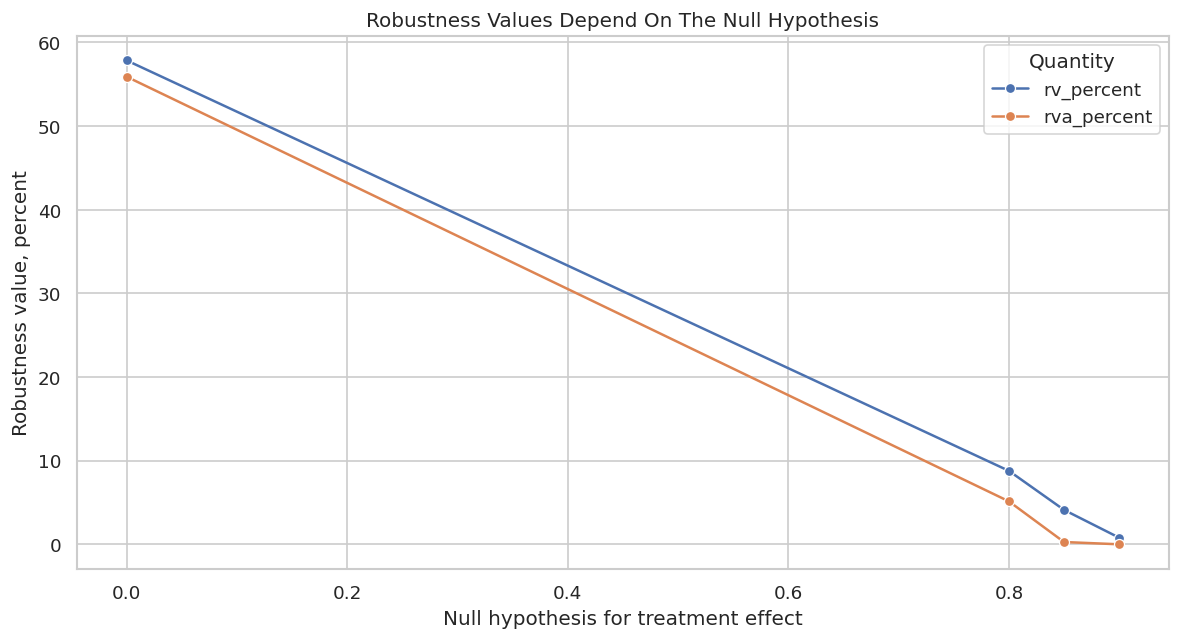

In [20]:
rv_plot = null_sensitivity.melt(
    id_vars=["null_hypothesis", "scenario"],
    value_vars=["rv_percent", "rva_percent"],
    var_name="robustness_value",
    value_name="percent",
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=rv_plot, x="null_hypothesis", y="percent", hue="robustness_value", marker="o", ax=ax)
ax.set_title("Robustness Values Depend On The Null Hypothesis")
ax.set_xlabel("Null hypothesis for treatment effect")
ax.set_ylabel("Robustness value, percent")
ax.legend(title="Quantity")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_robustness_by_null.png", bbox_inches="tight")
plt.show()

The curve falls as the null hypothesis gets closer to the observed estimate. This is a useful safeguard against vague language such as “the result is robust” without saying robust to what.

## Practical Reporting Language

The table below translates common sensitivity findings into careful reporting language. The goal is to avoid overstating what the analysis can prove.

In [21]:
reporting_language = pd.DataFrame(
    [
        {
            "finding": "Point estimate remains positive under modest sensitivity scenario",
            "careful wording": "Under the specified hidden-confounding scenario, the sensitivity-adjusted lower bound remains positive.",
            "avoid saying": "Hidden confounding is impossible.",
        },
        {
            "finding": "Benchmark-calibrated scenario moves the estimate materially",
            "careful wording": "A hidden factor comparable to the benchmarked observed proxies could materially reduce the estimate.",
            "avoid saying": "The benchmark proves the true bias size.",
        },
        {
            "finding": "Robustness value to zero is high",
            "careful wording": "Moving the point estimate to zero would require a hidden confounder of the reported strength under the model assumptions.",
            "avoid saying": "The result is automatically causal.",
        },
        {
            "finding": "RVa is much lower than RV",
            "careful wording": "Accounting for sampling uncertainty makes the conclusion more sensitive than the point estimate alone suggests.",
            "avoid saying": "The point-estimate robustness value is enough by itself.",
        },
    ]
)

save_table(reporting_language, f"{NOTEBOOK_PREFIX}_reporting_language.csv")
display(reporting_language)

,finding,careful wording,avoid saying
0,Point estimate remains positive under modest s...,Under the specified hidden-confounding scenari...,Hidden confounding is impossible.
1,Benchmark-calibrated scenario moves the estima...,A hidden factor comparable to the benchmarked ...,The benchmark proves the true bias size.
2,Robustness value to zero is high,Moving the point estimate to zero would requir...,The result is automatically causal.
3,RVa is much lower than RV,Accounting for sampling uncertainty makes the ...,The point-estimate robustness value is enough ...


Careful wording keeps sensitivity analysis in its proper role: a stress test for assumptions, not a replacement for design validation.

## Validation Plan

Sensitivity analysis should lead to better data questions. The table below lists concrete follow-up actions an analyst could take after seeing the sensitivity results.

In [22]:
validation_plan = pd.DataFrame(
    [
        {
            "risk": "Important unobserved user intent remains after proxy adjustment",
            "diagnostic_or_action": "Search for richer pre-treatment proxies or historical behavior features.",
            "expected benefit": "Reduce plausible cf_y and cf_d by measuring the hidden source more directly.",
        },
        {
            "risk": "Treatment timing may follow outcome anticipation",
            "diagnostic_or_action": "Audit feature timestamps and remove post-treatment variables from controls.",
            "expected benefit": "Protect the design from bad-control bias and reverse timing.",
        },
        {
            "risk": "Benchmark variables are weak comparisons for the hidden confounder",
            "diagnostic_or_action": "Benchmark several observed covariate groups separately and jointly.",
            "expected benefit": "Give readers multiple scales for plausible hidden-confounder strength.",
        },
        {
            "risk": "Sensitivity bounds are close to the decision threshold",
            "diagnostic_or_action": "Use a stronger design where possible: experiment, instrument, panel design, or negative control.",
            "expected benefit": "Shift credibility from modeling assumptions toward design-based evidence.",
        },
    ]
)

save_table(validation_plan, f"{NOTEBOOK_PREFIX}_validation_plan.csv")
display(validation_plan)

,risk,diagnostic_or_action,expected benefit
0,Important unobserved user intent remains after...,Search for richer pre-treatment proxies or his...,Reduce plausible cf_y and cf_d by measuring th...
1,Treatment timing may follow outcome anticipation,Audit feature timestamps and remove post-treat...,Protect the design from bad-control bias and r...
2,Benchmark variables are weak comparisons for t...,Benchmark several observed covariate groups se...,Give readers multiple scales for plausible hid...
3,Sensitivity bounds are close to the decision t...,Use a stronger design where possible: experime...,Shift credibility from modeling assumptions to...


A good sensitivity section does not end with a number. It should explain what data or design improvement would reduce the remaining uncertainty.

## Report Template And Artifact Manifest

The final cell writes a reusable report template and an artifact manifest. The template emphasizes the sensitivity parameters, benchmark calibration, and design caveats.

In [23]:
report_text = f"""
# Sensitivity Analysis Report Template

## Causal Design
- Outcome:
- Treatment:
- Observed controls:
- Main identification assumption:
- Main omitted-confounding concern:

## Main Estimate
- Point estimate:
- Standard error:
- Confidence interval:
- Primary DoubleML model:

## Sensitivity Scenario
- cf_y:
- cf_d:
- rho:
- Null hypothesis:
- Theta lower and upper bounds:
- CI lower and upper bounds:
- RV and RVa:

## Benchmark Calibration
- Benchmarking set(s):
- Benchmark cf_y and cf_d:
- Benchmark-calibrated bounds:
- Why these benchmarks are plausible or limited:

## Conclusion
- What remains stable under the tested scenario:
- What changes under stronger hidden confounding:
- What additional data or design would reduce concern:
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_report_template.md"
report_path.write_text(report_text)

artifact_manifest = pd.DataFrame(
    [
        {"artifact": "synthetic hidden-confounding data", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_hidden_confounding_data.csv")},
        {"artifact": "model comparison", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_model_comparison.csv")},
        {"artifact": "primary sensitivity", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_primary_sensitivity.csv")},
        {"artifact": "sensitivity grid", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_grid.csv")},
        {"artifact": "sensitivity benchmarks", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_benchmarks.csv")},
        {"artifact": "native DoubleML sensitivity plot", "path": str(native_plot_path)},
        {"artifact": "report template", "path": str(report_path)},
        {"artifact": "hidden confounding design figure", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_design.png")},
        {"artifact": "benchmark grid figure", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_grid_with_benchmarks.png")},
    ]
)

save_table(artifact_manifest, f"{NOTEBOOK_PREFIX}_artifact_manifest.csv")
display(Markdown(f"Report template written to `{report_path}`"))
display(artifact_manifest)

Report template written to `/home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/13_sensitivity_report_template.md`

,artifact,path
0,synthetic hidden-confounding data,/home/apex/Documents/ranking_sys/notebooks/tut...
1,model comparison,/home/apex/Documents/ranking_sys/notebooks/tut...
2,primary sensitivity,/home/apex/Documents/ranking_sys/notebooks/tut...
3,sensitivity grid,/home/apex/Documents/ranking_sys/notebooks/tut...
4,sensitivity benchmarks,/home/apex/Documents/ranking_sys/notebooks/tut...
5,native DoubleML sensitivity plot,/home/apex/Documents/ranking_sys/notebooks/tut...
6,report template,/home/apex/Documents/ranking_sys/notebooks/tut...
7,hidden confounding design figure,/home/apex/Documents/ranking_sys/notebooks/tut...
8,benchmark grid figure,/home/apex/Documents/ranking_sys/notebooks/tut...


The notebook now has a full DoubleML sensitivity workflow: omitted-confounding setup, realistic and oracle models, sensitivity bounds, observed-variable benchmarks, rho stress testing, robustness values, and reporting guidance.

## What Comes Next

The next natural topic is heterogeneous treatment effects: GATE, CATE-style summaries, best linear predictors, and how to talk about heterogeneity without confusing subgroup exploration with a new identification strategy.